# <font color='black'> Регрессионный анализ социально-экономических процессов, 2026 - 2027 </font>
## <font color='black'> Модель разность разностей (Difference-in-Differences) </font>

Давайте рассмотрим модель DiD на примере исследований Eissa, N. и Liebman, J.: авторы изучали эффект EITC (налогового вычета на трудовой доход) на занятость. Мы рассмотрим, как расширение EITC для женщин с детьми в 1993 г. повлияло на занятость женщин.

Краткое описание данных:

* year - год налогообложения
* work - дамми-переменная, показывающая факт занятости (1 - женщина, имеющая работу, 0 - в противном случае)
* age - возраст женщины
* ed - образование женщины (в количестве лет образования)
* children - количество детей у женщины
* nonwhite - дамми-переменная для расовой принадлежности
* unearn - non-labor income (разность семейного дохода и индивидуального дохода женщины)

In [1]:
import pandas as pd
import statsmodels.formula.api as statf
import matplotlib.pyplot as mpl
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
dta = pd.read_stata("DiDdata.dta")
dta = dta.dropna()
dta.head()

,state,year,urate,children,nonwhite,finc,earn,age,ed,work,unearn
0,11.0,1991.0,7.6,0,1,18714.394273,18714.394273,26,10,1,0.000000
1,12.0,1991.0,7.2,1,0,4838.568282,471.365639,22,9,1,4.367203
2,13.0,1991.0,6.4,2,0,8178.193833,0.000000,33,11,0,8.178194
3,14.0,1991.0,9.1,0,1,9369.570485,0.000000,43,11,0,9.369570
4,15.0,1991.0,8.6,3,1,14706.607930,14706.607930,23,7,1,0.000000


Для начала создадим дамми-переменные для обозначения группы воздействия и периода.

In [3]:
dta['treated'] = dta['children'].apply(lambda x: 1 if x > 0 else 0)
dta['after'] = dta['year'].apply(lambda x: 1 if x > 1993 else 0)

Проиллюстрируем на графике, как с течением времени изменялись средние значения занятости женщин в группе воздействия и контрольной группе. Этот график позволит понять, соблюдается ли допущение о параллельности трендов.

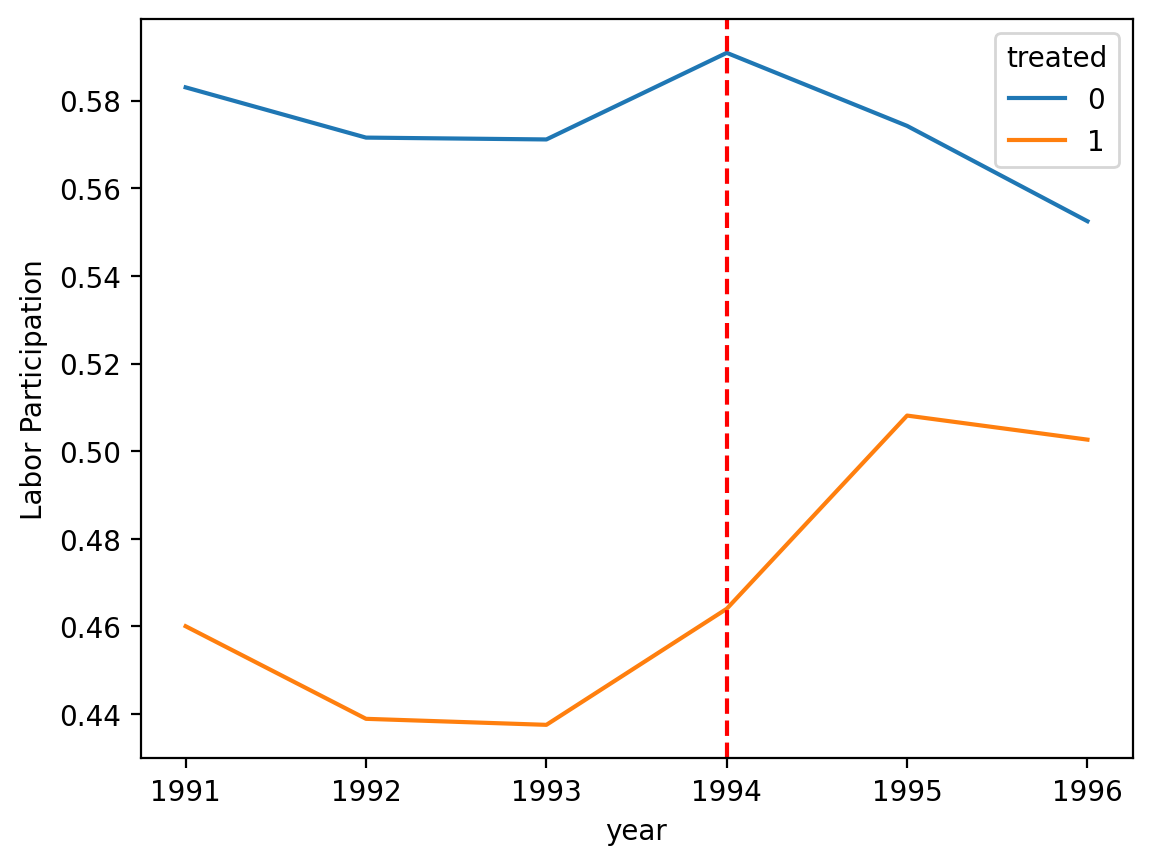

In [4]:
fig, axes = mpl.subplots()
dta.groupby(['year', 'treated']).mean()['work'].unstack().plot(ax = axes)
axes.set_ylabel("Labor Participation")
mpl.axvline(x=1994, color ='r', linestyle = '--')

Рассчитаем DiD-Оценку практически вручную. Для этого нам нужно  

1) посчитать разницу между средними значениями занятости в группе воздействия в период после и период до воздействия

2) посчитать соответствующую разницу для контрольной группы

3) и наконец-то, посчитать DiD (разность упомянутых выше разностей)

In [5]:
dta.groupby(['after', 'treated']).mean()['work']

dif_treated = dta.groupby(['after', 'treated']).mean()['work'].iloc[3] - dta.groupby(['after', 'treated']).mean()['work'].iloc[1]
dif_nontreated = dta.groupby(['after', 'treated']).mean()['work'].iloc[2] - dta.groupby(['after', 'treated']).mean()['work'].iloc[0]

did = dif_treated - dif_nontreated
did

np.float64(0.04687313210185562)

Теперь оценим соответствующую модель DiD. Видим, что оценка коэффициент при переменной взаимодействия совпадает с оценкой DiD, которую мы получили выше.

In [6]:
did_1 = statf.ols('work ~ treated*after', data=dta).fit(cov_type = "HC3")
print(did_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     58.64
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.17e-37
Time:                        21:10:39   Log-Likelihood:                -9884.9
No. Observations:               13746   AIC:                         1.978e+04
Df Residuals:                   13742   BIC:                         1.981e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.5755      0.009     65.364

Добавим контрольные переменные и посмотрим, изменился ли значимым образом эффект расширения EITC.

In [7]:
did_2 = statf.ols('work ~ treated*after + age + ed + nonwhite + unearn', data=dta).fit(cov_type = "HC3")
print(did_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   work   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     103.7
Date:                Sun, 04 Oct 2026   Prob (F-statistic):          1.66e-148
Time:                        21:10:39   Log-Likelihood:                -9311.5
No. Observations:               13746   AIC:                         1.864e+04
Df Residuals:                   13738   BIC:                         1.870e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4653      0.025     18.454